In [12]:
import sys
import os
print(os.getcwd())
sys.path.append(os.getcwd())
from utils import fcla as fc
from utils import simulation_utils as su
from utils import data_visualization as dv

c:\Users\alejo\Desktop\intro_la_inv


Test llm models

ollama

In [13]:
model = "qwen3:4b"
text = su.test_llm(model,"ollama")
print(text)

[Ollama] Verificando/Descargando el modelo 'qwen3:4b'...
 -> Status: pulling manifest
 -> Status: pulling 3e4cb1417446
 -> Status: pulling 2d54db2b9bb2
 -> Status: pulling d18a5cc71b84
 -> Status: pulling cff3f395ef37
 -> Status: pulling e18a783aae55
 -> Status: verifying sha256 digest
 -> Status: writing manifest
 -> Status: success
[Ollama] Procesando tu consulta...
[Ollama RESPUESTA]: 



Nvidia


# Simulations

## 1) Simulation withouth llms 

Inicializando entorno clásico
Starting Hybrid Simulation (FCNAgents + FCLAgents)...
# INITIALIZATION TIME 0.0260509
# EXECUTION TIME 0.2421759
Simulation complete successfully.
Data saved on './results/no_llms_base_results_fcn.csv'

=== ESTADÍSTICAS DE ÓRDENES colocadas ===
Órdenes totales de Agentes Clásicos (FCN): 600
Órdenes totales de Agentes con IA (LLM):  0

--- MUESTRA DE ÓRDENES CLÁSICAS (FCNAgent) ---
   market_time  agent_id  is_buy     price  volume         kind agent_type
0            0       270   False  19116.51       1  LIMIT_ORDER   FCNAgent
1            1         5    True  18205.70       1  LIMIT_ORDER   FCNAgent
2            2       482   False  20403.29       1  LIMIT_ORDER   FCNAgent
3            3       373    True  19506.50       1  LIMIT_ORDER   FCNAgent
4            4       382   False  19367.32       1  LIMIT_ORDER   FCNAgent
5            5       159    True  19578.37       1  LIMIT_ORDER   FCNAgent
6            6       236    True  19669.61       1  LIMIT_ORD

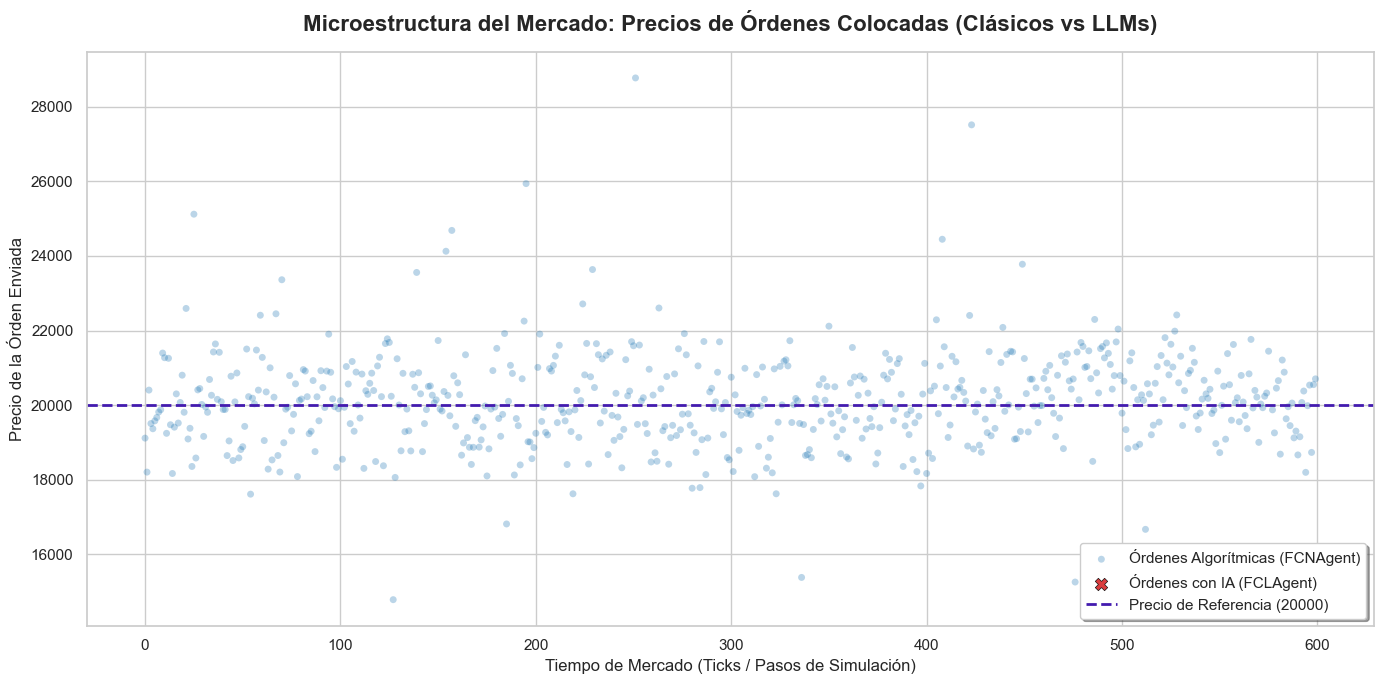

In [25]:

# Ignorar las advertencias de redondeo del tick size para limpiar la consola

market_runner, market_logger = su.run_sim("./jsons/default.json","no_llms")
llm_df,cls_df = su.agents_order_separation(market_runner,market_logger)
dv.plot_agent_actions_vs_time(cls_df,llm_df,20000)

In [18]:
import warnings

# Ignorar las advertencias de redondeo del tick size para limpiar la consola
warnings.filterwarnings("ignore", category=UserWarning, module="pams.market")
market_runner, market_logger = su.run_sim("./jsons/config.json","no_llms")




Inicializando entorno clásico
Starting Hybrid Simulation (FCNAgents + FCLAgents)...
# INITIALIZATION TIME 0.0125473
# EXECUTION TIME 0.4891419
Simulation complete successfully.
Data saved on './results/no_llms_base_results_fcn.csv'



=== ESTADÍSTICAS DE ÓRDENES colocadas ===
Órdenes totales de Agentes Clásicos (FCN): 2000
Órdenes totales de Agentes con IA (LLM):  0

--- MUESTRA DE ÓRDENES CLÁSICAS (FCNAgent) ---
   market_time  agent_id  is_buy   price  volume         kind agent_type
0            0       148    True  295.45       1  LIMIT_ORDER   FCNAgent
1            1       272   False  312.70       1  LIMIT_ORDER   FCNAgent
2            2       205    True  295.15       1  LIMIT_ORDER   FCNAgent
3            3       222    True  297.05       1  LIMIT_ORDER   FCNAgent
4            4       268    True  295.10       1  LIMIT_ORDER   FCNAgent
5            5       145   False  308.30       1  LIMIT_ORDER   FCNAgent
6            6       175   False  313.90       1  LIMIT_ORDER   FCNAgent
7            7       242   False  312.80       1  LIMIT_ORDER   FCNAgent
8            8       219   False  313.30       1  LIMIT_ORDER   FCNAgent
9            9       262   False  306.05       1  LIMIT_ORDER   FCNAgent

--- MUESTRA D

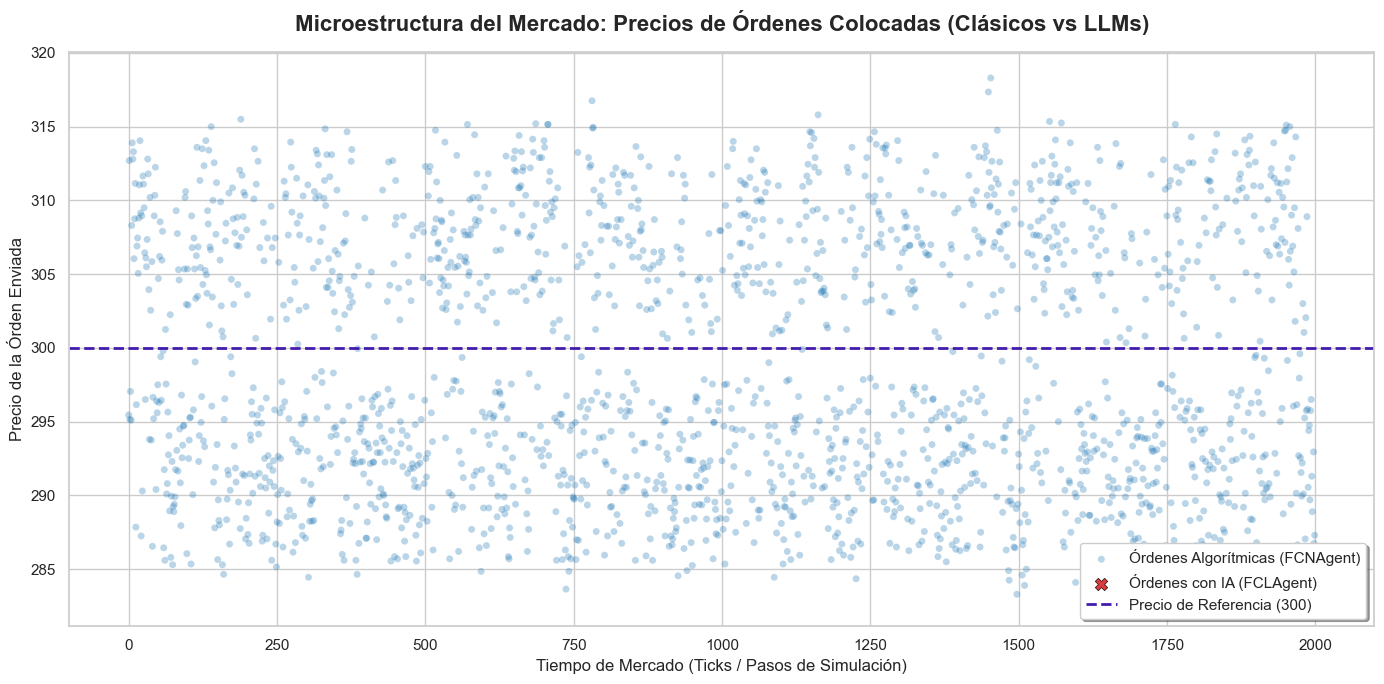

In [19]:
llm_df,cls_df = su.agents_order_separation(market_runner,market_logger)
dv.plot_agent_actions_vs_time(cls_df,llm_df,300)

Columnas exportadas por PAMS: ['session_id', 'market_time', 'market_id', 'market_name', 'market_price', 'fundamental_price']


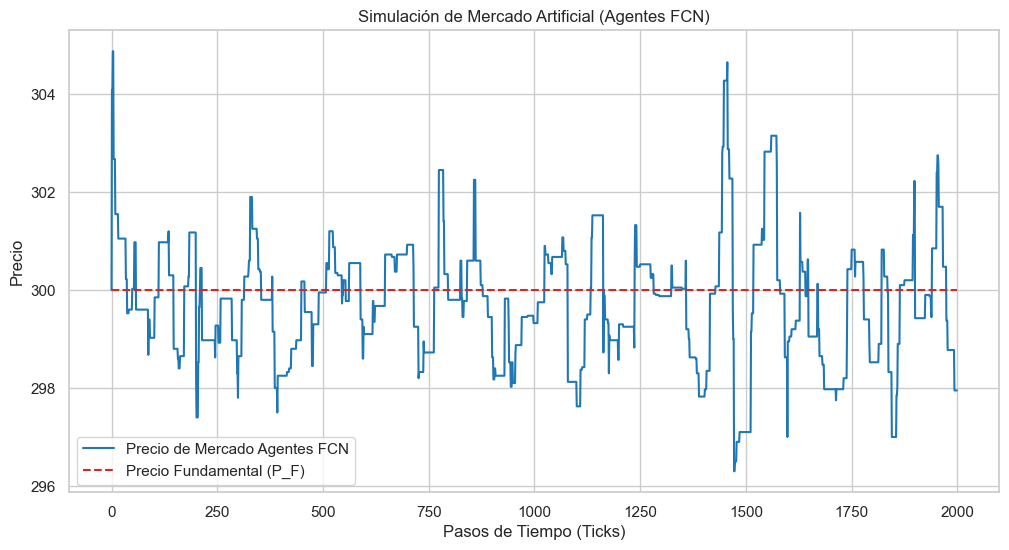

In [20]:
from utils import data_visualization as dv
r_path = "./results/no_llms_base_results_fcn.csv"
dv.market_behaviour(r_path)


## 2) Simulation with llms

In [28]:

from utils import personalities as pr
from utils import simulation_utils as su
import importlib
json_path = "./jsons/agenticConfig.json"
llm_runner,llm_logger = su.run_sim(json_path,"llm_hybrid",hybrid=True)
importlib.reload(fc)


Inicializando entorno híbrido...
Starting Hybrid Simulation (FCNAgents + FCLAgents)...
[SETUP] Agente FCL 395 creado con Personalidad: 'Baleas_Arriesgadas'
[SETUP] Agente FCL 396 creado con Personalidad: 'Baleas_Arriesgadas'
[SETUP] Agente FCL 397 creado con Personalidad: 'Conservadores_Miedosos'
[SETUP] Agente FCL 398 creado con Personalidad: 'Conservadores_Miedosos'
[SETUP] Agente FCL 399 creado con Personalidad: 'Conservadores_Miedosos'
  -> Agente 397 (Conservadores_Miedosos) - API (ollama): HOLD
  -> Agente 395 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 396 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 395 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 396 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 395 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 399 (Conservadores_Miedosos) - API (ollama): HOLD
# INITIALIZATION TIME 0.0243232
# EXECUTION TIME 371.5764181
Simulation complete successfully.
Data saved on './results/llm_hybrid_base_results_fcn

<module 'utils.fcla' from 'c:\\Users\\alejo\\Desktop\\intro_la_inv\\utils\\fcla.py'>

visualización 

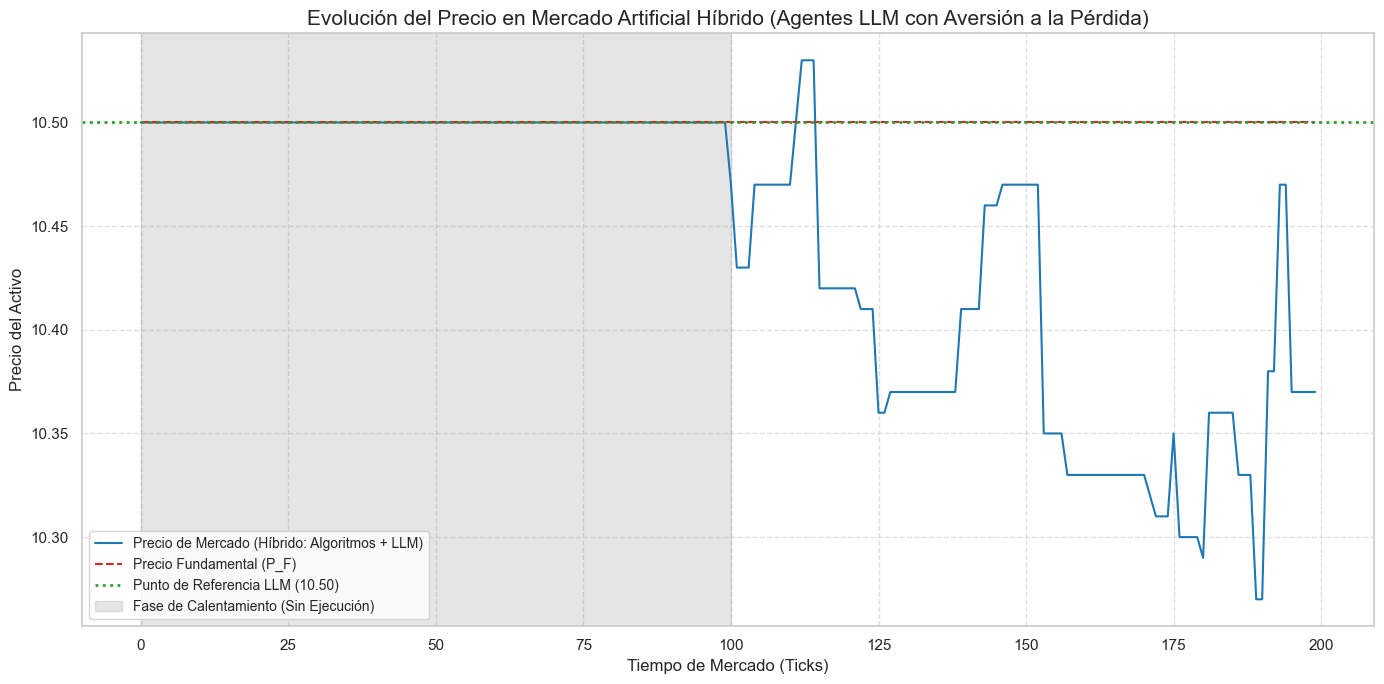


📊 RESUMEN ESTADÍSTICO DE LA SIMULACIÓN
▶ Precio Inicial:        10.4300
▶ Precio Final:          10.3700
▶ Precio Máximo (Pico):  10.5300
▶ Precio Mínimo (Caída): 10.2700
▶ Volatilidad (Desv. E): 0.0622


In [22]:
from utils import data_visualization as dv
import pandas as pd
import matplotlib.pyplot as plt
llm_r_path = "./results/llm_hybrid_base_results_fcn.csv"
dv.hybrid_market_behaviour(llm_r_path)
df = pd.read_csv(llm_r_path)
su.statistical_info(df)

 Análisis de Comportamiento Individual de Órdenes

In [23]:

llm_df,cls_df = su.agents_order_separation(llm_runner,llm_logger)


=== ESTADÍSTICAS DE ÓRDENES colocadas ===
Órdenes totales de Agentes Clásicos (FCN): 193
Órdenes totales de Agentes con IA (LLM):  7

--- MUESTRA DE ÓRDENES CLÁSICAS (FCNAgent) ---
   market_time  agent_id  is_buy  price  volume         kind agent_type
0            0        39   False  10.22       1  LIMIT_ORDER   FCNAgent
1            1        68    True   9.97       1  LIMIT_ORDER   FCNAgent
2            2        19   False  11.42       1  LIMIT_ORDER   FCNAgent
3            3        94    True   9.77       1  LIMIT_ORDER   FCNAgent
4            4        34   False  10.63       1  LIMIT_ORDER   FCNAgent
5            5        64   False  10.33       1  LIMIT_ORDER   FCNAgent
6            6        44    True  10.70       1  LIMIT_ORDER   FCNAgent
7            7        13    True  10.13       1  LIMIT_ORDER   FCNAgent
8            8        18   False  10.27       1  LIMIT_ORDER   FCNAgent
9            9        20    True  10.72       1  LIMIT_ORDER   FCNAgent

--- MUESTRA DE ÓRDENES DE

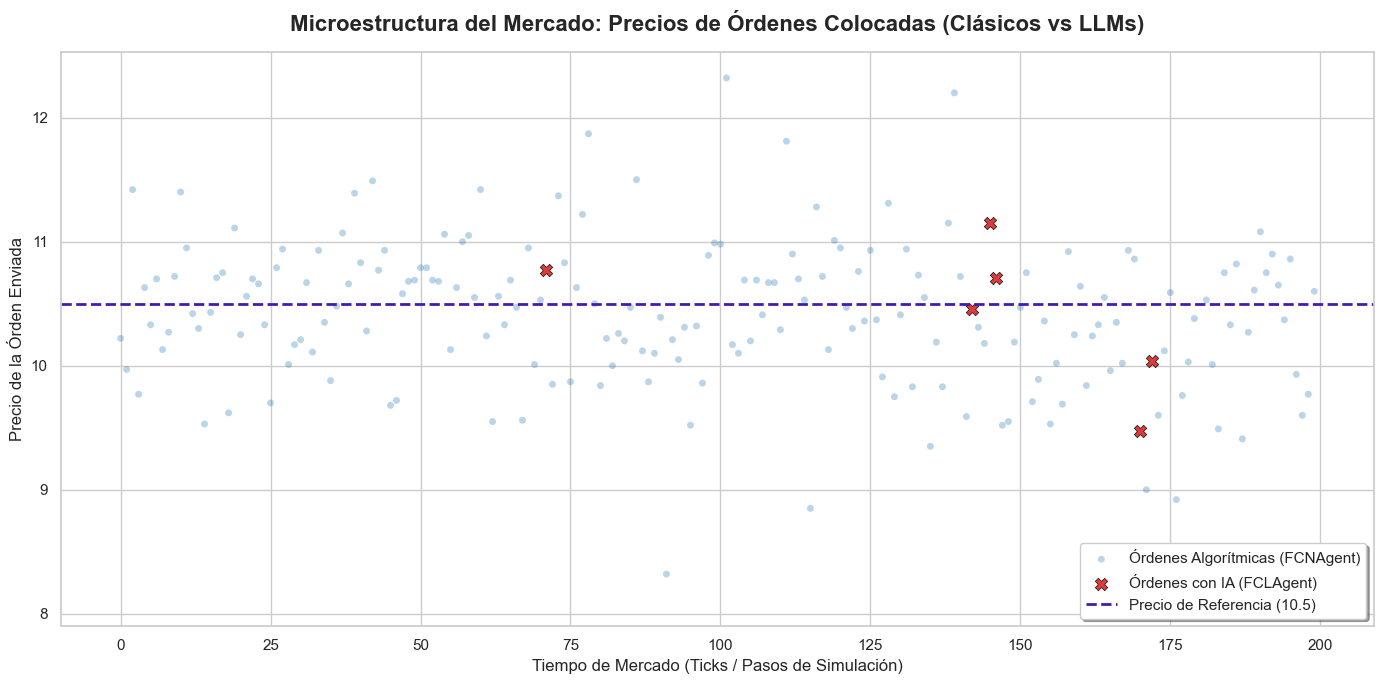

In [24]:

dv.plot_agent_actions_vs_time(cls_df,llm_df,10.50)
